# ¿Cuánto le cuesta la rotación a una embotelladora?

Análisis de People Analytics sobre una empresa **ficticia** de unos 500 colaboradores (octubre 2023 a septiembre 2026), con montos en bolivianos (Bs). Responde cuatro preguntas:

1. ¿Dónde se concentra la rotación?
2. ¿En qué momento se va la gente?
3. ¿Cuánto cuesta en plata?
4. ¿Quién tiene más probabilidad de renunciar en los próximos 12 meses y cuánta plata está en juego?

> Los datos se generan con `generar_datos.py` (semilla fija, así que los resultados se reproducen). Los números ilustran el método: no describen a ninguna empresa real.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import graficos as g

g.aplicar_estilo()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATOS, IMG, RESULTADOS = Path("datos"), Path("img"), Path("resultados")
IMG.mkdir(exist_ok=True)
RESULTADOS.mkdir(exist_ok=True)

colaboradores = pd.read_csv(DATOS / "colaboradores.csv", parse_dates=["fecha_ingreso", "fecha_egreso"])
planilla = pd.read_csv(DATOS / "planilla_mensual.csv", parse_dates=["fecha_periodo"])
supuestos = pd.read_csv(DATOS / "supuestos_costos.csv")

print(f"{len(colaboradores):,} colaboradores | {len(planilla):,} filas de planilla | "
      f"{planilla['periodo'].min()} a {planilla['periodo'].max()}")

830 colaboradores | 18,360 filas de planilla | 2023-10 a 2026-09


## 1. Los datos

- `colaboradores.csv`: una fila por persona (activa o que ya se fue), con área, cargo, nivel, turno, fechas de ingreso y egreso, tipo de egreso, edad al ingresar, distancia del domicilio, *compa-ratio* (sueldo frente al punto medio de su banda) y última evaluación de desempeño.
- `planilla_mensual.csv`: una fila por persona y mes, con días trabajados, días de ausencia, horas extra y el costo laboral completo.
- `supuestos_costos.csv`: los supuestos para calcular cuánto cuesta reemplazar a alguien, por nivel. Se pueden editar.

In [2]:
FIN = pd.Timestamp("2026-09-30")
INICIO_12M = pd.Timestamp("2025-10-01")

egresos = colaboradores.dropna(subset=["fecha_egreso"]).copy()
egresos["antiguedad_meses"] = (egresos["fecha_egreso"] - egresos["fecha_ingreso"]).dt.days / 30.44
renuncias = egresos[egresos["tipo_egreso"] == "Renuncia voluntaria"].copy()
dotacion_mensual = planilla.groupby("periodo")["id_colaborador"].nunique()

pd.Series({
    "Dotación en oct-2023": dotacion_mensual.iloc[0],
    "Dotación en sep-2026": dotacion_mensual.iloc[-1],
    "Egresos en los 3 años": len(egresos),
    "Renuncias voluntarias": len(renuncias),
    "Desvinculaciones": int((egresos["tipo_egreso"] == "Desvinculación").sum()),
}).to_frame("cantidad")

,cantidad
Dotación en oct-2023,500
Dotación en sep-2026,520
Egresos en los 3 años,323
Renuncias voluntarias,250
Desvinculaciones,73


## 2. ¿Dónde se concentra la rotación?

Rotación voluntaria de los últimos 12 meses = renuncias del período / dotación promedio del período.

In [3]:
ultimos_12 = planilla[planilla["fecha_periodo"] >= INICIO_12M].merge(
    colaboradores[["id_colaborador", "area"]], on="id_colaborador")
dotacion_promedio = (ultimos_12.groupby(["periodo", "area"])["id_colaborador"].nunique()
                     .groupby("area").mean())
renuncias_12m = renuncias[renuncias["fecha_egreso"] >= INICIO_12M]

por_area = pd.DataFrame({
    "dotacion_promedio": dotacion_promedio,
    "renuncias": renuncias_12m.groupby("area").size(),
}).fillna(0)
por_area["rotacion_voluntaria"] = por_area["renuncias"] / por_area["dotacion_promedio"]
por_area = por_area.sort_values("rotacion_voluntaria", ascending=False)

rotacion_empresa = por_area["renuncias"].sum() / por_area["dotacion_promedio"].sum()
print(f"Rotación voluntaria de la empresa en los últimos 12 meses: {g.porcentaje(rotacion_empresa, 1)}")
por_area

Rotación voluntaria de la empresa en los últimos 12 meses: 16,6%


,dotacion_promedio,renuncias,rotacion_voluntaria
area,,,
Logística y Distribución,117.58,36.00,0.31
Ventas,74.75,16.00,0.21
Producción,208.50,29.00,0.14
Mantenimiento,41.00,3.00,0.07
Administración y Finanzas,44.00,2.00,0.05
Calidad,31.00,0.00,0.00


PosixPath('img/01_rotacion_por_area.png')

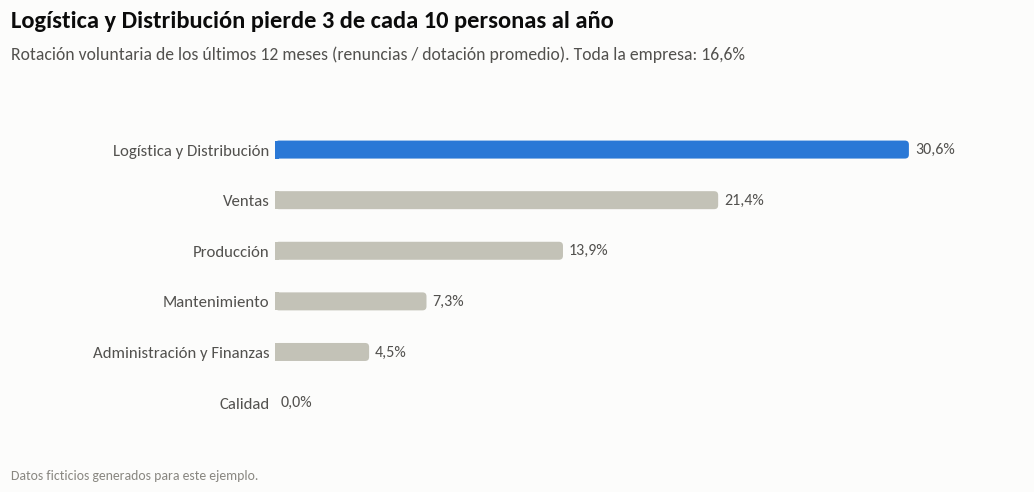

In [4]:
area_top = por_area.index[0]
tasa_top = por_area["rotacion_voluntaria"].iloc[0]

fig, ax = g.figura(alto=4.6, ejes=(0.26, 0.12, 0.68, 0.62))
g.encabezado(fig, f"{area_top} pierde {round(tasa_top * 10)} de cada 10 personas al año",
             f"Rotación voluntaria de los últimos 12 meses (renuncias / dotación promedio). "
             f"Toda la empresa: {g.porcentaje(rotacion_empresa, 1)}")
g.barras_horizontales(
    ax, por_area.index, por_area["rotacion_voluntaria"].values,
    [g.AZUL] + [g.GRIS] * (len(por_area) - 1),
    textos=[g.porcentaje(v, 1) for v in por_area["rotacion_voluntaria"]])
g.pie(fig)
g.guardar(fig, IMG / "01_rotacion_por_area.png")

## 3. ¿En qué momento se va la gente?

Primero, cuántas renuncias hubo según la antigüedad al momento de irse. Después, la **tasa** de renuncia de cada tramo: renuncias divididas por los meses-persona que la gente pasó en ese tramo. La tasa corrige el hecho de que hay más gente antigua que nueva.

In [5]:
cortes = [0, 3, 6, 12, 24, 60, np.inf]
tramos = ["< 3 meses", "3 a 6 meses", "6 a 12 meses", "1 a 2 años", "2 a 5 años", "> 5 años"]

renuncias["tramo"] = pd.cut(renuncias["antiguedad_meses"], cortes, labels=tramos, right=False)
cantidad_por_tramo = renuncias["tramo"].value_counts().reindex(tramos)

# Exposición: meses-persona de cada tramo dentro del período observado
exposicion = planilla.merge(colaboradores[["id_colaborador", "fecha_ingreso"]], on="id_colaborador")
exposicion["antiguedad_meses"] = (exposicion["fecha_periodo"] - exposicion["fecha_ingreso"]).dt.days / 30.44
exposicion["tramo"] = pd.cut(exposicion["antiguedad_meses"].clip(lower=0), cortes, labels=tramos, right=False)
meses_persona = exposicion.groupby("tramo", observed=False)["dias_trabajados"].sum() / 30

por_tramo = pd.DataFrame({
    "renuncias": cantidad_por_tramo,
    "porcentaje_de_renuncias": cantidad_por_tramo / cantidad_por_tramo.sum(),
    "tasa_anual": cantidad_por_tramo / meses_persona * 12,
})
primer_anio = por_tramo["porcentaje_de_renuncias"].iloc[:3].sum()
tasa_6m = renuncias["antiguedad_meses"].lt(6).sum() / meses_persona.iloc[:2].sum() * 12
tasa_2a = renuncias["antiguedad_meses"].ge(24).sum() / meses_persona.iloc[4:].sum() * 12
veces = tasa_6m / tasa_2a
print(f"Renuncias antes de cumplir un año: {g.porcentaje(primer_anio)} del total")
veces_texto = g.miles(veces, 1).replace(",0", "")
print(f"Tasa anual de renuncia con menos de 6 meses: {g.porcentaje(tasa_6m)}; con 2 años o más: "
      f"{g.porcentaje(tasa_2a)} ({veces_texto} veces menos)")
por_tramo

Renuncias antes de cumplir un año: 49% del total
Tasa anual de renuncia con menos de 6 meses: 49%; con 2 años o más: 8% (6 veces menos)


,renuncias,porcentaje_de_renuncias,tasa_anual
tramo,,,
< 3 meses,37,0.15,0.41
3 a 6 meses,38,0.15,0.60
6 a 12 meses,48,0.19,0.43
1 a 2 años,39,0.16,0.22
2 a 5 años,45,0.18,0.11
> 5 años,43,0.17,0.07


PosixPath('img/02_cuando_se_van.png')

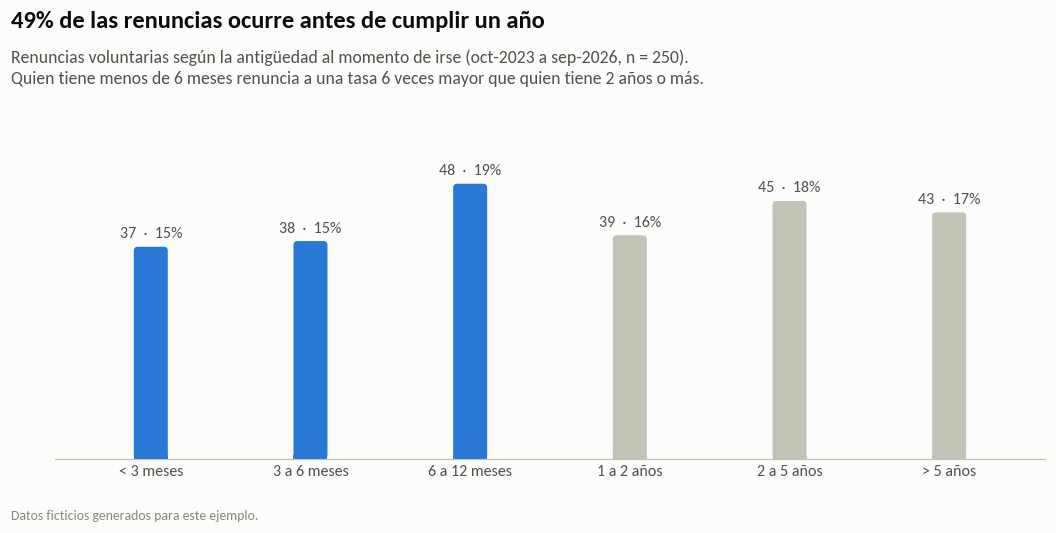

In [6]:
fig, ax = g.figura(alto=5.0, ejes=(0.06, 0.14, 0.90, 0.60))
g.encabezado(fig, f"{g.porcentaje(primer_anio)} de las renuncias ocurre antes de cumplir un año",
             f"Renuncias voluntarias según la antigüedad al momento de irse (oct-2023 a sep-2026, n = {len(renuncias)}).\n"
             f"Quien tiene menos de 6 meses renuncia a una tasa {veces_texto} veces mayor que quien tiene 2 años o más.")
g.columnas(ax, tramos, por_tramo["renuncias"].values, [g.AZUL] * 3 + [g.GRIS] * 3,
           textos=[f"{int(n)}  ·  {g.porcentaje(p)}" for n, p in
                   zip(por_tramo["renuncias"], por_tramo["porcentaje_de_renuncias"])])
g.pie(fig)
g.guardar(fig, IMG / "02_cuando_se_van.png")

## 4. ¿Cuánto cuesta?

Costo de reemplazar a una persona que renuncia (supuestos en `datos/supuestos_costos.csv`):

| Componente | Cálculo |
|---|---|
| Reclutamiento y selección | monto fijo por nivel (avisos, horas de RRHH, exámenes) |
| Inducción y capacitación | meses de sueldo invertidos en formar al reemplazo |
| Curva de aprendizaje | meses hasta rendir al 100% × productividad que falta en ese tiempo × sueldo |
| Vacante | días con el puesto vacío, cubiertos con horas extra que se pagan al doble (se cuenta el recargo) |

Se calcula con el haber básico de la persona al irse.

In [7]:
RECARGO_HORAS_EXTRA = 2.0

def costo_reemplazo(tabla, columna_sueldo):
    t = tabla[["nivel", columna_sueldo]].merge(supuestos, on="nivel", how="left")
    t.index = tabla.index  # el merge reinicia el índice: se recupera el original
    sueldo = t[columna_sueldo]
    componentes = pd.DataFrame({
        "reclutamiento": t["reclutamiento_bs"],
        "induccion": t["induccion_meses_sueldo"] * sueldo,
        "curva_aprendizaje": t["meses_curva_aprendizaje"] * (1 - t["productividad_en_curva"]) * sueldo,
        "vacante": t["dias_vacante"] / 30 * sueldo * (RECARGO_HORAS_EXTRA - 1),
    }, index=tabla.index)
    return componentes

componentes = costo_reemplazo(renuncias, "haber_basico_actual_bs")
renuncias["costo_reemplazo_bs"] = componentes.sum(axis=1)
renuncias["meses_de_sueldo"] = renuncias["costo_reemplazo_bs"] / renuncias["haber_basico_actual_bs"]

(renuncias.groupby("nivel")[["haber_basico_actual_bs", "costo_reemplazo_bs", "meses_de_sueldo"]]
 .mean().rename(columns={"haber_basico_actual_bs": "sueldo_promedio_bs"}))

,sueldo_promedio_bs,costo_reemplazo_bs,meses_de_sueldo
nivel,,,
Operativo,"3,706.26","9,971.47",2.69
Profesional y jefatura,"13,650.00","72,885.00",5.34
Técnico y supervisión,"6,482.87","24,217.61",3.74


In [8]:
renuncias_12m = renuncias[renuncias["fecha_egreso"] >= INICIO_12M]
costo_12m = renuncias_12m["costo_reemplazo_bs"].sum()
costo_por_area = renuncias_12m.groupby("area")["costo_reemplazo_bs"].sum().sort_values(ascending=False)

# Inversión perdida: reclutamiento + inducción de quienes se fueron antes de los 6 meses
tempranas = renuncias_12m["antiguedad_meses"] < 6
perdida_temprana = componentes.loc[renuncias_12m.index[tempranas], ["reclutamiento", "induccion"]].sum().sum()
planilla_12m = planilla.loc[planilla["fecha_periodo"] >= INICIO_12M, "costo_total_bs"].sum()

print(f"Costo de la rotación voluntaria en los últimos 12 meses: {g.bs(costo_12m)} "
      f"({len(renuncias_12m)} renuncias, {g.bs(costo_12m / len(renuncias_12m))} por renuncia)")
print(f"Equivale al {g.porcentaje(costo_12m / planilla_12m, 1)} del costo laboral anual")
print(f"Inversión en reclutamiento e inducción perdida en renuncias de menos de 6 meses: {g.bs(perdida_temprana)}")
costo_por_area.to_frame("costo_bs")

Costo de la rotación voluntaria en los últimos 12 meses: Bs 966.625 (86 renuncias, Bs 11.240 por renuncia)
Equivale al 1,7% del costo laboral anual
Inversión en reclutamiento e inducción perdida en renuncias de menos de 6 meses: Bs 90.526


,costo_bs
area,
Logística y Distribución,"380,635.10"
Producción,"323,165.92"
Ventas,"184,435.45"
Mantenimiento,"57,637.00"
Administración y Finanzas,"20,751.13"


PosixPath('img/03_costo_por_area.png')

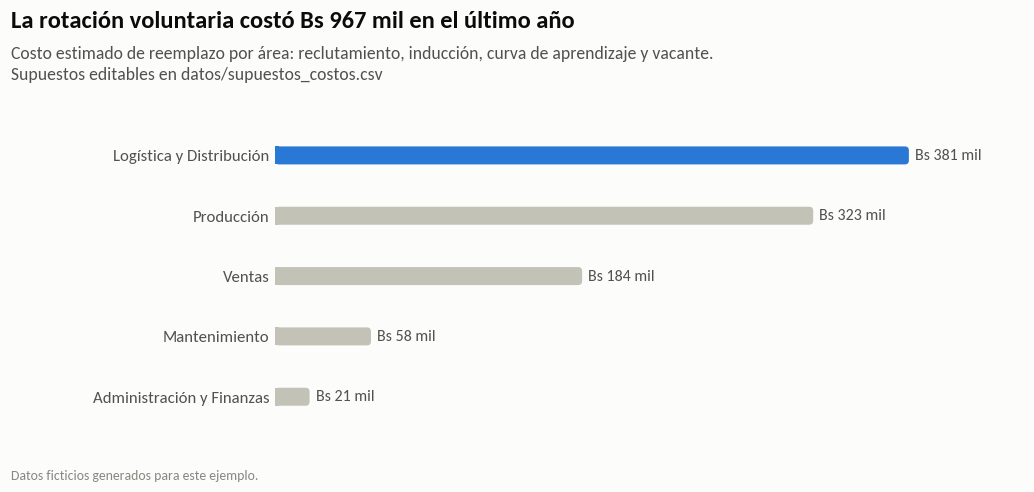

In [9]:
fig, ax = g.figura(alto=4.6, ejes=(0.26, 0.12, 0.68, 0.62))
g.encabezado(fig, f"La rotación voluntaria costó {g.bs_compacto(costo_12m)} en el último año",
             "Costo estimado de reemplazo por área: reclutamiento, inducción, curva de aprendizaje y vacante.\n"
             "Supuestos editables en datos/supuestos_costos.csv")
g.barras_horizontales(
    ax, costo_por_area.index, costo_por_area.values,
    [g.AZUL] + [g.GRIS] * (len(costo_por_area) - 1),
    textos=[g.bs_compacto(v) for v in costo_por_area.values])
g.pie(fig)
g.guardar(fig, IMG / "03_costo_por_area.png")

## 5. ¿Quién tiene más probabilidad de renunciar?

**Diseño.** Se toma una "foto" de todas las personas activas al 30 de septiembre de 2025, con sus variables a esa fecha, y se marca quién renunció en los 12 meses siguientes. Con eso se entrena el modelo. Después se aplica a la foto de hoy (30 de septiembre de 2026) para estimar el riesgo de los próximos 12 meses.

**Variables:** antigüedad (por tramos), horas extra promedio de los últimos 6 meses, días de ausencia del último año (anualizados), compa-ratio, distancia al trabajo, edad, desempeño, área, nivel y turno.

**Modelo:** regresión logística. Se eligió porque se puede explicar: cada variable tiene un efecto que se lee como "multiplica el riesgo por X". Quienes fueron desvinculados durante la ventana se excluyen: no renunciaron, pero tampoco se quedaron.

In [10]:
TRAMOS_MODELO = ["< 6 meses", "6 a 12 meses", "1 a 2 años", "2 a 5 años", "> 5 años"]

def foto(fecha_corte):
    """Personas activas al cierre de fecha_corte, con sus variables calculadas a esa fecha."""
    corte = pd.Timestamp(fecha_corte)
    activos = colaboradores[(colaboradores["fecha_ingreso"] <= corte)
                            & (colaboradores["fecha_egreso"].isna() | (colaboradores["fecha_egreso"] > corte))].copy()
    historia = planilla[planilla["fecha_periodo"] <= corte]
    ultimos_6 = historia[historia["fecha_periodo"] > corte - pd.DateOffset(months=6)]
    ultimos_12 = historia[historia["fecha_periodo"] > corte - pd.DateOffset(months=12)]
    activos = activos.join(ultimos_6.groupby("id_colaborador")["horas_extra"].mean().rename("horas_extra_prom"),
                           on="id_colaborador")
    activos = activos.join((ultimos_12.groupby("id_colaborador")["dias_ausencia"].mean() * 12)
                           .rename("ausencias_anuales"), on="id_colaborador")
    activos["antiguedad_meses"] = (corte - activos["fecha_ingreso"]).dt.days / 30.44
    activos["edad"] = activos["edad_ingreso"] + activos["antiguedad_meses"] / 12
    activos["tramo_antiguedad"] = pd.cut(activos["antiguedad_meses"], [0, 6, 12, 24, 60, np.inf],
                                         labels=TRAMOS_MODELO, right=False).astype(str)
    return activos

corte = pd.Timestamp("2025-09-30")
fin_ventana = corte + pd.DateOffset(months=12)
base = foto(corte)
egresa_en_ventana = base["fecha_egreso"].notna() & (base["fecha_egreso"] <= fin_ventana)
base["renuncio_12m"] = (egresa_en_ventana & (base["tipo_egreso"] == "Renuncia voluntaria")).astype(int)
base = base[~(egresa_en_ventana & (base["tipo_egreso"] == "Desvinculación"))]

print(f"Personas en la foto de entrenamiento: {len(base)} | renunciaron en los 12 meses siguientes: "
      f"{base['renuncio_12m'].sum()} ({g.porcentaje(base['renuncio_12m'].mean(), 1)})")
print("La tasa es menor que la rotación anual porque la foto no incluye a quienes entran y renuncian dentro del mismo año.")

Personas en la foto de entrenamiento: 475 | renunciaron en los 12 meses siguientes: 53 (11,2%)
La tasa es menor que la rotación anual porque la foto no incluye a quienes entran y renuncian dentro del mismo año.


In [11]:
NUMERICAS = ["horas_extra_prom", "ausencias_anuales", "compa_ratio", "distancia_km", "edad", "evaluacion_desempeno"]
CATEGORICAS = ["tramo_antiguedad", "area", "nivel", "turno"]
REFERENCIAS = {"tramo_antiguedad": "> 5 años", "area": "Producción", "nivel": "Operativo", "turno": "Diurno"}

categorias = [sorted(colaboradores[c].unique()) if c != "tramo_antiguedad" else TRAMOS_MODELO for c in CATEGORICAS]
preparacion = ColumnTransformer([
    ("num", StandardScaler(), NUMERICAS),
    ("cat", OneHotEncoder(categories=categorias, drop=[REFERENCIAS[c] for c in CATEGORICAS]), CATEGORICAS),
])
modelo = Pipeline([("prep", preparacion), ("logit", LogisticRegression(max_iter=1000))])

X, y = base[NUMERICAS + CATEGORICAS], base["renuncio_12m"]
validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
prob_cv = cross_val_predict(modelo, X, y, cv=validacion, method="predict_proba")[:, 1]

auc = roc_auc_score(y, prob_cv)
umbral = np.quantile(prob_cv, 0.80)
captura_20 = y[prob_cv >= umbral].sum() / y.sum()
print(f"AUC en validación cruzada (5 particiones): {g.miles(auc, 2)}")
print(f"El 20% con más riesgo según el modelo concentra el {g.porcentaje(captura_20)} de las renuncias reales")

# Calibración: probabilidad promedio vs. tasa real por quintil de riesgo
quintil = pd.qcut(prob_cv, 5, labels=["1 (menor riesgo)", "2", "3", "4", "5 (mayor riesgo)"])
pd.DataFrame({"probabilidad_promedio": prob_cv, "renuncio": y.values}).groupby(quintil, observed=False).mean()

AUC en validación cruzada (5 particiones): 0,78
El 20% con más riesgo según el modelo concentra el 53% de las renuncias reales


,probabilidad_promedio,renuncio
1 (menor riesgo),0.01,0.00
2,0.03,0.04
3,0.07,0.12
4,0.13,0.11
5 (mayor riesgo),0.32,0.29


In [12]:
modelo.fit(X, y)
escala = modelo.named_steps["prep"].named_transformers_["num"].scale_
coeficientes = pd.Series(modelo.named_steps["logit"].coef_[0],
                         index=modelo.named_steps["prep"].get_feature_names_out())

def nombre_legible(variable):
    tipo, nombre = variable.split("__", 1)
    if tipo == "num":
        desvio = dict(zip(NUMERICAS, escala))[nombre]
        return {
            "horas_extra_prom": f"+{desvio:.0f} horas extra al mes",
            "ausencias_anuales": f"+{desvio:.0f} días de ausencia al año",
            "compa_ratio": f"Sueldo {desvio * 100:.0f}% más alto dentro de su banda",
            "distancia_km": f"+{desvio:.0f} km de distancia al trabajo",
            "edad": f"+{desvio:.0f} años de edad",
            "evaluacion_desempeno": f"+{g.miles(desvio, 1)} puntos de desempeño",
        }[nombre]
    columna, categoria = nombre.rsplit("_", 1)
    referencia = REFERENCIAS[columna]
    if columna == "tramo_antiguedad":
        return f"Antigüedad {categoria} (vs. {referencia})"
    if columna == "area":
        return f"{categoria} (vs. {referencia})"
    if columna == "nivel":
        return f"{categoria} (vs. operativo)"
    return f"Turno {categoria.lower()} (vs. diurno)"

DESCRIPCION_NUMERICA = {  # cómo describir a una persona con valor alto / bajo en cada variable
    "horas_extra_prom": ("Muchas horas extra", "Pocas horas extra"),
    "ausencias_anuales": ("Ausencias altas", "Pocas ausencias"),
    "compa_ratio": ("Sueldo alto dentro de su banda", "Sueldo bajo dentro de su banda"),
    "distancia_km": ("Vive lejos del trabajo", "Vive cerca del trabajo"),
    "edad": ("Mayor edad", "Menor edad"),
    "evaluacion_desempeno": ("Desempeño alto", "Desempeño bajo"),
}

def factor_de_la_persona(variable, valor_estandarizado):
    tipo, nombre = variable.split("__", 1)
    if tipo == "num":
        alto, bajo = DESCRIPCION_NUMERICA[nombre]
        return alto if valor_estandarizado > 0 else bajo
    columna, categoria = nombre.rsplit("_", 1)
    return {"tramo_antiguedad": f"Antigüedad {categoria}", "area": f"Área {categoria}",
            "nivel": f"Nivel {categoria.lower()}", "turno": f"Turno {categoria.lower()}"}[columna]

efectos = pd.DataFrame({"variable": [nombre_legible(v) for v in coeficientes.index],
                        "multiplica_el_riesgo_por": np.exp(coeficientes.values)},
                       index=coeficientes.index)
efectos = efectos.reindex(coeficientes.abs().sort_values(ascending=False).index)
efectos

,variable,multiplica_el_riesgo_por
cat__tramo_antiguedad_6 a 12 meses,Antigüedad 6 a 12 meses (vs. > 5 años),3.04
cat__tramo_antiguedad_< 6 meses,Antigüedad < 6 meses (vs. > 5 años),2.93
cat__area_Calidad,Calidad (vs. Producción),0.37
num__compa_ratio,Sueldo 8% más alto dentro de su banda,0.43
cat__nivel_Profesional y jefatura,Profesional y jefatura (vs. operativo),0.44
cat__tramo_antiguedad_1 a 2 años,Antigüedad 1 a 2 años (vs. > 5 años),2.29
cat__area_Ventas,Ventas (vs. Producción),2.20
num__horas_extra_prom,+10 horas extra al mes,1.60
num__ausencias_anuales,+3 días de ausencia al año,1.52
cat__area_Logística y Distribución,Logística y Distribución (vs. Producción),1.42


PosixPath('img/04_factores_de_riesgo.png')

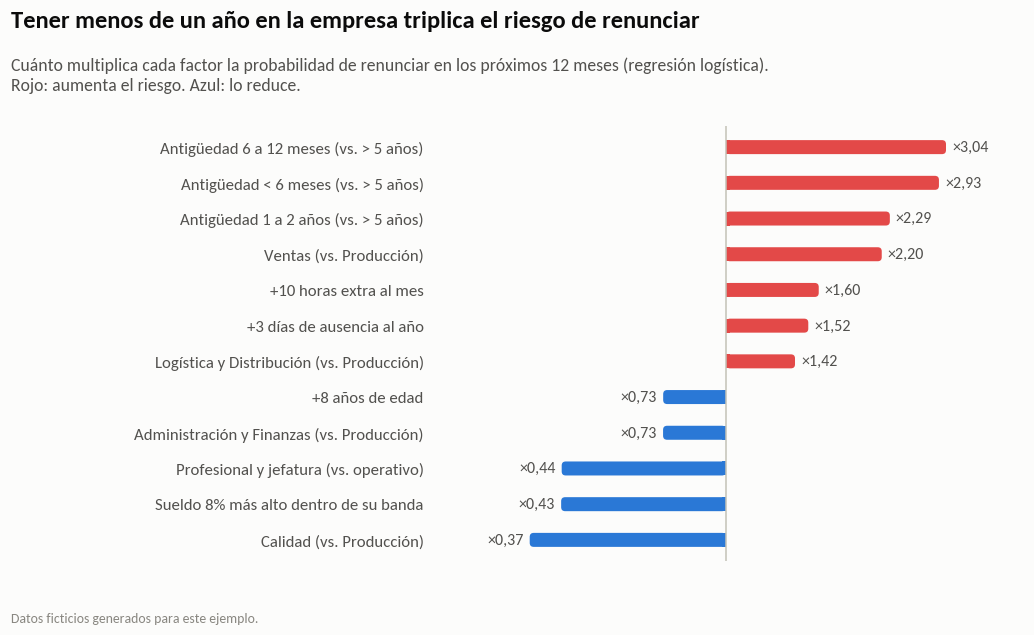

In [13]:
principales = efectos.head(12).sort_values("multiplica_el_riesgo_por", ascending=False)
log_efecto = np.log(principales["multiplica_el_riesgo_por"].values)

fig, ax = g.figura(alto=6.0, ejes=(0.40, 0.12, 0.54, 0.66))
g.encabezado(fig, "Tener menos de un año en la empresa triplica el riesgo de renunciar",
             "Cuánto multiplica cada factor la probabilidad de renunciar en los próximos 12 meses (regresión logística).\n"
             "Rojo: aumenta el riesgo. Azul: lo reduce.")
limite = np.abs(log_efecto).max() * 1.35
g.barras_horizontales(
    ax, principales["variable"], log_efecto,
    [g.ROJO if v > 0 else g.AZUL for v in log_efecto],
    textos=[f"×{g.miles(m, 2)}" for m in principales["multiplica_el_riesgo_por"]],
    x_min=-limite, x_max=limite, grosor_px=14)
ax.axvline(0, color=g.EJE, linewidth=1)
g.pie(fig)
g.guardar(fig, IMG / "04_factores_de_riesgo.png")

## 6. ¿Cuánta plata está en juego hoy?

Se aplica el modelo a las personas activas al 30 de septiembre de 2026. Para cada una:

- **Probabilidad de renunciar** en los próximos 12 meses.
- **Costo de reemplazo** con su sueldo actual.
- **Costo esperado** = probabilidad × costo de reemplazo. Sumado, da los bolivianos en riesgo.

También se marca el **factor principal** de cada persona: la variable que más sube su riesgo. Sirve para saber qué conversación tener con cada uno.

In [14]:
hoy = foto("2026-09-30")
hoy["prob_renuncia_12m"] = modelo.predict_proba(hoy[NUMERICAS + CATEGORICAS])[:, 1]
hoy["costo_reemplazo_bs"] = costo_reemplazo(hoy, "haber_basico_actual_bs").sum(axis=1)
hoy["costo_esperado_bs"] = hoy["prob_renuncia_12m"] * hoy["costo_reemplazo_bs"]

# Factor principal: la variable con el mayor aporte positivo al riesgo de cada persona
matriz = modelo.named_steps["prep"].transform(hoy[NUMERICAS + CATEGORICAS])
matriz = matriz.toarray() if hasattr(matriz, "toarray") else matriz
valores = pd.DataFrame(matriz, columns=coeficientes.index, index=hoy.index)
aportes = valores * coeficientes.values
hoy["factor_principal"] = [
    factor_de_la_persona(v, valores.loc[i, v]) if aportes.loc[i, v] > 0 else "Sin factor destacado"
    for i, v in aportes.idxmax(axis=1).items()]

renuncias_esperadas = hoy["prob_renuncia_12m"].sum()
bs_en_riesgo = hoy["costo_esperado_bs"].sum()
print(f"Personas activas: {len(hoy)} | renuncias esperadas en 12 meses: {renuncias_esperadas:.0f} | "
      f"bolivianos en riesgo: {g.bs(bs_en_riesgo)}")

riesgo_por_area = (hoy.groupby("area")
                   .agg(personas=("id_colaborador", "count"),
                        renuncias_esperadas=("prob_renuncia_12m", "sum"),
                        bs_en_riesgo=("costo_esperado_bs", "sum"))
                   .sort_values("bs_en_riesgo", ascending=False))
riesgo_por_area

Personas activas: 507 | renuncias esperadas en 12 meses: 62 | bolivianos en riesgo: Bs 770.660


,personas,renuncias_esperadas,bs_en_riesgo
area,,,
Producción,207,27.32,"316,691.13"
Logística y Distribución,111,18.26,"218,759.39"
Ventas,74,10.37,"125,778.02"
Mantenimiento,40,3.27,"67,295.15"
Administración y Finanzas,44,1.31,"27,047.74"
Calidad,31,1.09,"15,088.69"


PosixPath('img/05_bs_en_riesgo.png')

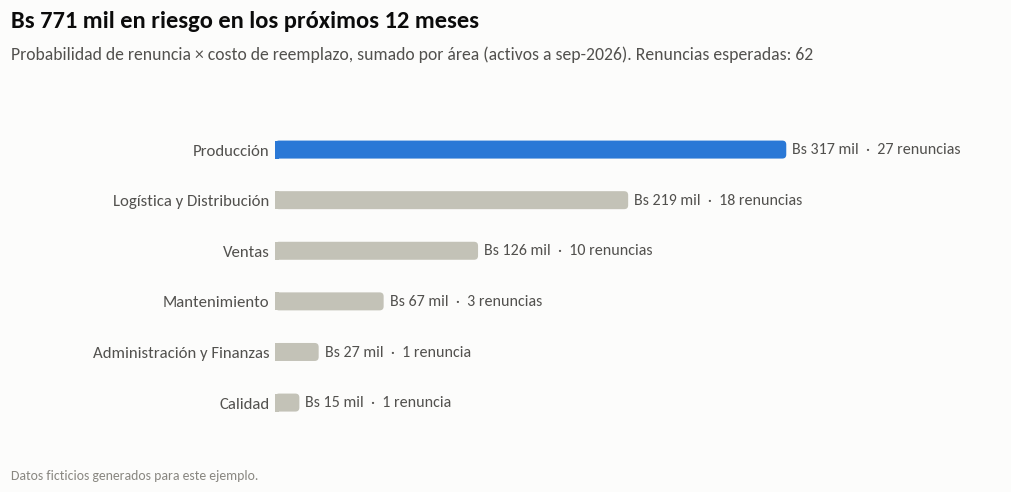

In [15]:
fig, ax = g.figura(alto=4.6, ejes=(0.26, 0.12, 0.66, 0.62))
g.encabezado(fig, f"{g.bs_compacto(bs_en_riesgo)} en riesgo en los próximos 12 meses",
             f"Probabilidad de renuncia × costo de reemplazo, sumado por área (activos a sep-2026). "
             f"Renuncias esperadas: {renuncias_esperadas:.0f}")
g.barras_horizontales(
    ax, riesgo_por_area.index, riesgo_por_area["bs_en_riesgo"].values,
    [g.AZUL] + [g.GRIS] * (len(riesgo_por_area) - 1),
    textos=[f"{g.bs_compacto(v)}  ·  {round(r)} renuncia{'' if round(r) == 1 else 's'}" for v, r in
            zip(riesgo_por_area["bs_en_riesgo"], riesgo_por_area["renuncias_esperadas"])],
    x_max=riesgo_por_area["bs_en_riesgo"].max() * 1.42)
g.pie(fig)
g.guardar(fig, IMG / "05_bs_en_riesgo.png")

In [16]:
columnas = ["id_colaborador", "area", "cargo", "antiguedad_meses", "prob_renuncia_12m",
            "costo_reemplazo_bs", "costo_esperado_bs", "factor_principal"]
lista = hoy[columnas].sort_values("costo_esperado_bs", ascending=False)
lista.round({"antiguedad_meses": 1, "prob_renuncia_12m": 3, "costo_reemplazo_bs": 0, "costo_esperado_bs": 0}) \
     .to_csv(RESULTADOS / "riesgo_actual.csv", index=False)
lista.head(10)

,id_colaborador,area,cargo,antiguedad_meses,prob_renuncia_12m,costo_reemplazo_bs,costo_esperado_bs,factor_principal
651,C0652,Logística y Distribución,Jefe de logística,18.66,0.16,"74,208.00","12,235.71",Ausencias altas
820,C0821,Logística y Distribución,Auxiliar de almacén,0.95,0.84,"10,304.57","8,706.39",Ausencias altas
772,C0773,Producción,Operario de línea,5.58,0.87,"9,729.47","8,448.71",Ausencias altas
616,C0617,Producción,Ingeniero de procesos,21.65,0.11,"67,318.60","7,488.36",Sueldo bajo dentro de su banda
417,C0418,Mantenimiento,Técnico eléctrico,47.57,0.29,"25,280.00","7,394.62",Muchas horas extra
799,C0800,Producción,Auxiliar de producción,3.25,0.79,"8,868.00","7,020.48",Sueldo bajo dentro de su banda
776,C0777,Mantenimiento,Técnico mecánico,5.32,0.27,"25,035.45","6,841.70",Antigüedad < 6 meses
811,C0812,Logística y Distribución,Ayudante de reparto,2.46,0.65,"10,304.57","6,694.41",Antigüedad < 6 meses
801,C0802,Logística y Distribución,Ayudante de reparto,3.19,0.75,"8,868.00","6,660.49",Sueldo bajo dentro de su banda
804,C0805,Logística y Distribución,Chofer repartidor,2.96,0.67,"9,826.50","6,619.74",Antigüedad < 6 meses


## 7. Qué haría con esto

Lo que sale de este análisis, en orden de impacto:

In [17]:
tempranas_12m = renuncias_12m[renuncias_12m["antiguedad_meses"] < 12]
ahorro_onboarding = tempranas_12m["costo_reemplazo_bs"].sum() * 0.30

print("1) Cuidar el primer año.")
print(f"   {len(tempranas_12m)} de las {len(renuncias_12m)} renuncias del último año fueron de personas con menos de 12 meses.")
print(f"   Si un programa de inducción y seguimiento las baja un 30%, el ahorro estimado es de {g.bs(ahorro_onboarding)} al año.")
print()
area_costo = costo_por_area.index[0]
area_riesgo = riesgo_por_area.index[0]
print(f"2) Primero {area_costo}" + (f"; después, {area_riesgo}." if area_riesgo != area_costo else "."))
print(f"   {area_costo} concentra {g.porcentaje(costo_por_area.iloc[0] / costo_12m)} del costo de la rotación del último año "
      f"(rotación voluntaria de {g.porcentaje(por_area.loc[area_costo, 'rotacion_voluntaria'])}).")
if area_riesgo != area_costo:
    print(f"   {area_riesgo}, por su tamaño, concentra {g.porcentaje(riesgo_por_area['bs_en_riesgo'].iloc[0] / bs_en_riesgo)} "
          f"de los bolivianos en riesgo de los próximos 12 meses.")
print()
print("3) Usar la lista de riesgo como agenda, no como sentencia.")
print("   resultados/riesgo_actual.csv ordena a las personas por costo esperado y dice el factor principal de cada una:")
print("   sirve para priorizar entrevistas de permanencia, revisar horas extra o sueldos fuera de banda.")

1) Cuidar el primer año.
   50 de las 86 renuncias del último año fueron de personas con menos de 12 meses.
   Si un programa de inducción y seguimiento las baja un 30%, el ahorro estimado es de Bs 158.479 al año.

2) Primero Logística y Distribución; después, Producción.
   Logística y Distribución concentra 39% del costo de la rotación del último año (rotación voluntaria de 31%).
   Producción, por su tamaño, concentra 41% de los bolivianos en riesgo de los próximos 12 meses.

3) Usar la lista de riesgo como agenda, no como sentencia.
   resultados/riesgo_actual.csv ordena a las personas por costo esperado y dice el factor principal de cada una:
   sirve para priorizar entrevistas de permanencia, revisar horas extra o sueldos fuera de banda.


## 8. Límites del análisis

- **Los datos son ficticios.** Con datos reales hay que reentrenar el modelo y revisar los supuestos de costo junto con Finanzas.
- **Correlación no es causa.** El modelo dice quién se parece a los que se fueron, no por qué se fueron. Las ausencias, por ejemplo, pueden ser un síntoma de que la persona ya está buscando otro trabajo, más que una causa.
- **Una sola foto de entrenamiento.** Con más historia conviene usar varias fotos (una por trimestre) y validar en el tiempo, no solo con validación cruzada.
- **El costo es una estimación conservadora.** No incluye el efecto en el clima del equipo, los errores de quien recién aprende ni el tiempo de los jefes en entrevistas.